<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

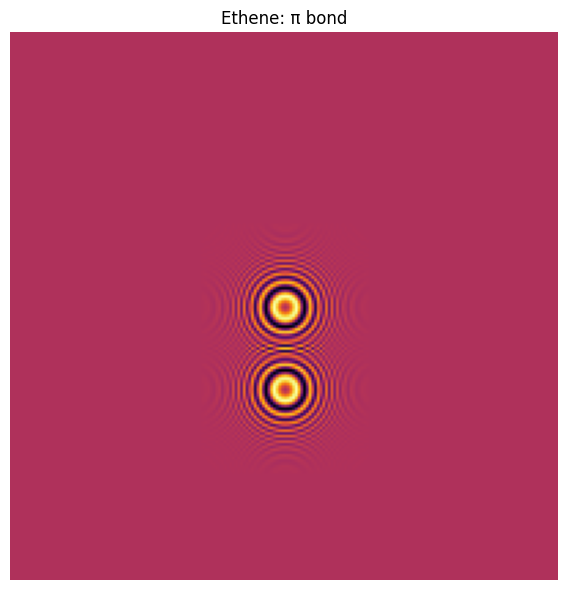

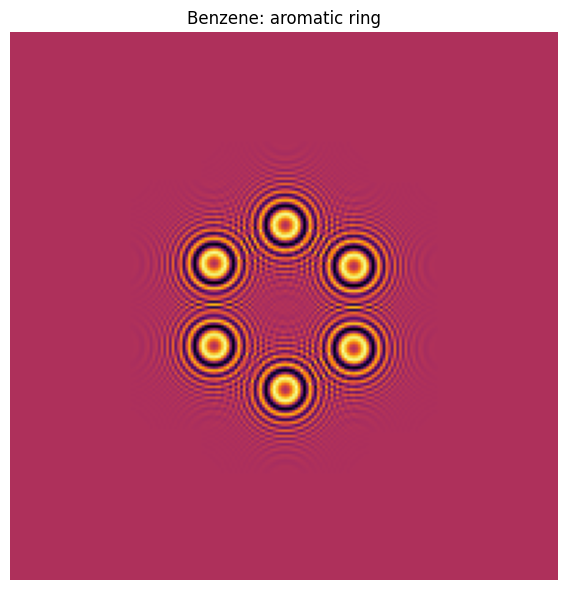

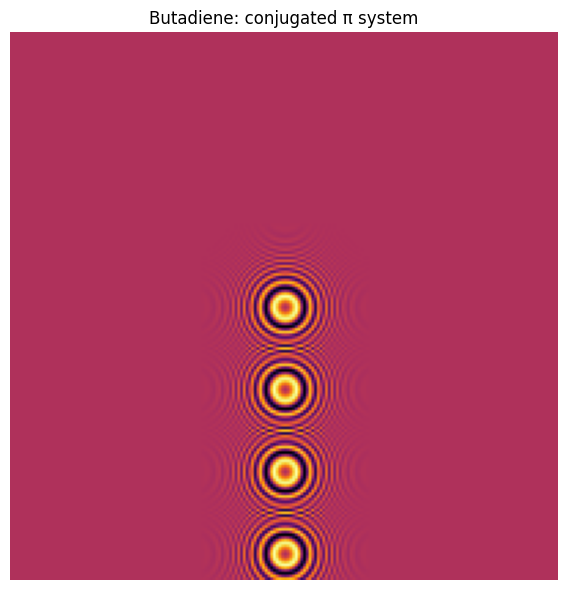

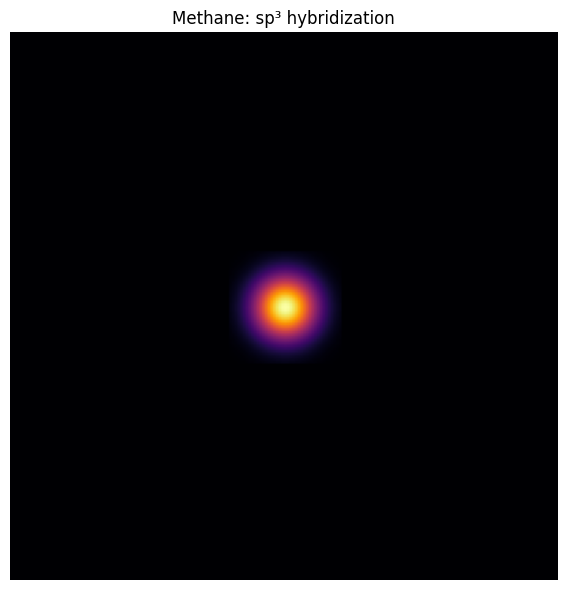

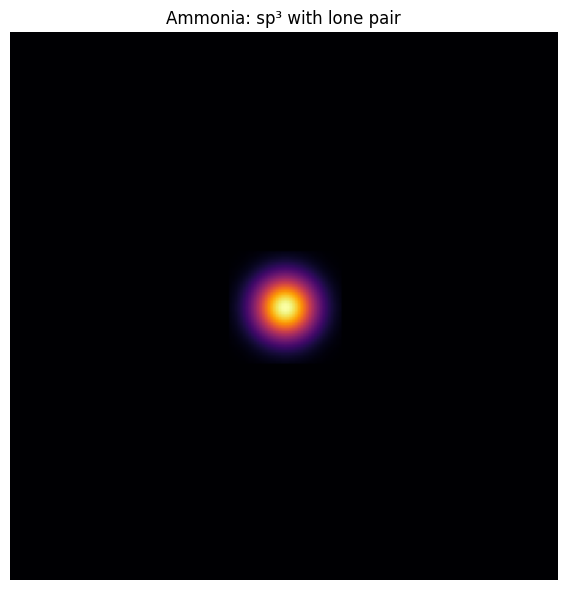

    Molecule         Orbital Type  Delocalization Extent  Curvature Coherence
0     Ethene               π bond                   1103               0.0957
1    Benzene        aromatic ring                   2926               0.1600
2  Butadiene  conjugated π system                   1951               0.1324
3    Methane    sp³ hybridization                    933               0.0702
4    Ammonia   sp³ with lone pair                    933               0.0702


In [1]:
# Chem010: Molecular Orbitals via Curvature Field Interference

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define molecules and orbital configurations
molecules = {
    "Ethene": {
        "type": "π bond",
        "atoms": [(0, 0), (1, 0)],
        "orbitals": ["pz", "pz"]
    },
    "Benzene": {
        "type": "aromatic ring",
        "atoms": [(np.cos(t), np.sin(t)) for t in np.linspace(0, 2*np.pi, 6, endpoint=False)],
        "orbitals": ["pz"] * 6
    },
    "Butadiene": {
        "type": "conjugated π system",
        "atoms": [(i, 0) for i in range(4)],
        "orbitals": ["pz"] * 4
    },
    "Methane": {
        "type": "sp³ hybridization",
        "atoms": [(0, 0)],
        "orbitals": ["sp3", "sp3", "sp3", "sp3"]
    },
    "Ammonia": {
        "type": "sp³ with lone pair",
        "atoms": [(0, 0)],
        "orbitals": ["sp3", "sp3", "sp3", "lp"]
    }
}

# Orbital field simulation
def simulate_orbitals(name, data):
    atoms = data["atoms"]
    orbitals = data["orbitals"]
    field = np.zeros((200, 200))
    extent = 0
    coherence = 0

    for i, (x, y) in enumerate(atoms):
        cx, cy = int(100 + x * 30), int(100 + y * 30)
        orb_type = orbitals[i % len(orbitals)]
        if orb_type == "pz":
            sigma = 10
            for dx in range(-30, 31):
                for dy in range(-30, 31):
                    xi, yi = cx + dx, cy + dy
                    if 0 <= xi < 200 and 0 <= yi < 200:
                        r2 = dx**2 + dy**2
                        field[xi, yi] += np.sin(r2 / (sigma + 1)) * np.exp(-r2 / (2 * sigma**2))
        elif orb_type == "sp3":
            sigma = 8
            for dx in range(-20, 21):
                for dy in range(-20, 21):
                    xi, yi = cx + dx, cy + dy
                    if 0 <= xi < 200 and 0 <= yi < 200:
                        r2 = dx**2 + dy**2
                        field[xi, yi] += np.exp(-r2 / (2 * sigma**2))
        elif orb_type == "lp":
            sigma = 6
            for dx in range(-15, 16):
                for dy in range(-15, 16):
                    xi, yi = cx + dx, cy + dy
                    if 0 <= xi < 200 and 0 <= yi < 200:
                        r2 = dx**2 + dy**2
                        field[xi, yi] += 1.5 * np.exp(-r2 / (2 * sigma**2))

    # Normalize and compute metrics
    field /= np.max(field)
    extent = np.sum(field > 0.1)
    coherence = np.std(field)

    # Visualize field
    plt.figure(figsize=(6, 6))
    plt.imshow(field, cmap='inferno', extent=[-3, 3, -3, 3])
    plt.title(f"{name}: {data['type']}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return {
        "Molecule": name,
        "Orbital Type": data["type"],
        "Delocalization Extent": extent,
        "Curvature Coherence": round(coherence, 4)
    }

# Run simulation
summary = [simulate_orbitals(name, data) for name, data in molecules.items()]
df = pd.DataFrame(summary)
print(df)
